In [1]:
import torch
import gc

# Очищаем кэш GPU
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()


# Принудительный сборщик мусора
gc.collect()

# Проверяем результат
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory cached: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU memory allocated: 0.00 GB
GPU memory cached: 0.00 GB


In [2]:
import sys
import os
import torch
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import csv
from transformers import (
    AutoModelForCausalLM,
    AutoConfig,
    AutoTokenizer  
)
from torch.utils.data import DataLoader
from datasets import load_dataset


/home/user/projects/FedCore/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
correct_path = "/home/user/projects/FedCore"
sys.path.insert(0, correct_path)

In [4]:
device_cuda = torch.device("cuda") if torch.cuda.is_available() else None
if device_cuda is None:
    print("CUDA недоступна, измерения будут только на CPU")
DEVICES = ["cpu"] if device_cuda is None else ["cpu", "cuda"]

# Params

In [ ]:
BATCH_SIZES = [2, 4, 8]
SEQ_LENS = [64, 128, 256]
WARMUP_ITERS = 10
MEASURE_ITERS = 5

USE_MODIFIED = False
MODIFIED_CLASSES = {}

## Attention layers

In [5]:
try:
    from transformers.models.qwen2.modeling_qwen2 import Qwen2Attention
    from transformers.models.gemma2.modeling_gemma2 import Gemma2Attention
    # from transformers.models.llama.modeling_llama import LlamaAttention

    MODIFIED_CLASSES = {
        "Qwen/Qwen2.5-0.5B": Qwen2Attention,
        "google/gemma-2-2b": Gemma2Attention,
        # "meta-llama/Llama-3.2-1B": LlamaAttention,
    }
    USE_MODIFIED = True
    print("Модифицированные классы внимания успешно импортированы.")
except ImportError as e:
    print(f"Модифицированные классы не найдены: {e}")
    print("Будут измерены только оригинальные модели.")

csv_filename = "attention_times.csv"
ATTN_IMPLEMENTATION = 'eager'

Модифицированные классы внимания успешно импортированы.


## Flash-Attention layers

In [ ]:
try:
    from transformers.models.qwen2.modeling_qwen2 import Qwen2FlashAttention2
    from transformers.models.gemma2.modeling_gemma2 import Gemma2FlashAttention2
    from transformers.models.llama.modeling_llama import LlamaFlashAttention2

    MODIFIED_CLASSES = {
        "Qwen/Qwen2.5-0.5B": Qwen2FlashAttention2,
        "google/gemma-2-2b": Gemma2FlashAttention2,
        "meta-llama/Llama-3.2-1B": LlamaFlashAttention2,
    }
    USE_MODIFIED = True
    print("Модифицированные классы внимания успешно импортированы.")
except ImportError as e:
    print(f"Модифицированные классы не найдены: {e}")
    print("Будут измерены только оригинальные модели.")

csv_filename = "flash_attention_times.csv"
ATTN_IMPLEMENTATION = 'flash_attention_2'

## SDP Attention

In [6]:
try:
    from transformers.models.qwen2.modeling_qwen2 import Qwen2SdpaAttention
    from transformers.models.gemma2.modeling_gemma2 import Gemma2SdpaAttention
    # from transformers.models.llama.modeling_llama import LlamaSdpaAttention

    MODIFIED_CLASSES = {
        "Qwen/Qwen2.5-0.5B": Qwen2SdpaAttention,
        "google/gemma-2-2b": Gemma2SdpaAttention,
        # "meta-llama/Llama-3.2-1B": LlamaSdpaAttention,
    }
    USE_MODIFIED = True
    print("Модифицированные классы внимания успешно импортированы.")
except ImportError as e:
    print(f"Модифицированные классы не найдены: {e}")
    print("Будут измерены только оригинальные модели.")

ATTN_IMPLEMENTATION = 'sdpa'
csv_filename = "sdp_attention_times.csv"

Модифицированные классы внимания успешно импортированы.


# Main 

In [7]:
def get_first_attention_layer(model):
    for name, module in model.named_modules():
        if "self_attn" in name:
            return module
    raise ValueError("Attention layer not founded")

In [8]:
def measure_attention_time(attn_module, batch_size, seq_len, device, hidden_size):
    hidden_states = torch.randn(batch_size, seq_len, hidden_size, device=device)
    position_ids = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, -1)

    for _ in range(WARMUP_ITERS):
        with torch.no_grad():
            _ = attn_module(hidden_states, attention_mask=None, position_ids=position_ids)

    times = []
    for _ in range(MEASURE_ITERS):
        if device.type == "cuda":
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            start_event.record()
            with torch.no_grad():
                _ = attn_module(hidden_states, attention_mask=None, position_ids=position_ids)
            end_event.record()
            torch.cuda.synchronize()
            elapsed_ms = start_event.elapsed_time(end_event)
        else:
            start = time.perf_counter()
            with torch.no_grad():
                _ = attn_module(hidden_states, attention_mask=None, position_ids=position_ids)
            elapsed_ms = (time.perf_counter() - start) * 1000.0
        times.append(elapsed_ms)

    return sum(times) / len(times)

In [9]:
model_configs = []

original_models = [
    ("Qwen/Qwen2.5-0.5B", "Qwen-2.5-0.5B (original)"),
    ("google/gemma-2-2b", "Gemma2 (original)"),
    # ("openlm-research/open_llama_3b_v2", "OpenLLaMA-3B (original)"),
]
for model_name, display_name in original_models:
    model_configs.append({
        "hf_name": model_name,
        "display_name": display_name,
        "modified": False,
        "attn_class": None
    })

if USE_MODIFIED:
    modified_models = [
        ("Qwen/Qwen2.5-0.5B", "Qwen-2.5-0.5B (pruned)"),
        ("google/gemma-2-2b", "Gemma2 (pruned)"),
        # ("meta-llama/Llama-3.2-1B", "LLama (pruned)"),
    ]
    for model_name, display_name in modified_models:
        model_configs.append({
            "hf_name": model_name,
            "display_name": display_name,
            "modified": True,
            "attn_class": MODIFIED_CLASSES.get(model_name)
        })


In [10]:
results = []

for cfg in model_configs:
    print(f"\n=== {cfg['display_name']} ===")
    model_name = cfg["hf_name"]
    
    config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        config=config,
        torch_dtype=torch.float32,
        trust_remote_code=True,
        attn_implementation=ATTN_IMPLEMENTATION,
    )
    model.eval()
    
    if cfg["modified"] and cfg["attn_class"] is not None:
        attn_class = cfg["attn_class"]
        old_attn = get_first_attention_layer(model)
        new_attn = attn_class(config, layer_idx=0)
        new_attn.load_state_dict(old_attn.state_dict())
        for name, module in model.named_modules():
            if hasattr(module, "self_attn") and module.self_attn is old_attn:
                module.self_attn = new_attn
                break
    
    attn_module = get_first_attention_layer(model)
    hidden_size = config.hidden_size
    
    for device_name in DEVICES:
        device = torch.device(device_name)
        print(f"  Device: {device_name.upper()}")
        model.to(device)
        attn_module.to(device)
        
        for batch_size in BATCH_SIZES:
            for seq_len in SEQ_LENS:
                print(f"    batch={batch_size}, seq_len={seq_len}", end="", flush=True)
                avg_time = measure_attention_time(attn_module, batch_size, seq_len, device, hidden_size)
                results.append({
                        "model": cfg["display_name"],
                        "device": device_name,
                        "batch_size": batch_size,
                        "seq_len": seq_len,
                        "time_ms": avg_time
                    })
    
    del model
    torch.cuda.empty_cache()


=== Qwen-2.5-0.5B (original) ===
  Device: CPU
    batch=2, seq_len=64    batch=2, seq_len=128    batch=2, seq_len=256    batch=4, seq_len=64    batch=4, seq_len=128    batch=4, seq_len=256    batch=8, seq_len=64    batch=8, seq_len=128    batch=8, seq_len=256  Device: CUDA
    batch=2, seq_len=64    batch=2, seq_len=128    batch=2, seq_len=256    batch=4, seq_len=64    batch=4, seq_len=128    batch=4, seq_len=256    batch=8, seq_len=64    batch=8, seq_len=128    batch=8, seq_len=256
=== Gemma2 (original) ===


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 15.81it/s]


  Device: CPU
    batch=2, seq_len=64    batch=2, seq_len=128    batch=2, seq_len=256    batch=4, seq_len=64    batch=4, seq_len=128    batch=4, seq_len=256    batch=8, seq_len=64    batch=8, seq_len=128    batch=8, seq_len=256  Device: CUDA
    batch=2, seq_len=64    batch=2, seq_len=128    batch=2, seq_len=256    batch=4, seq_len=64    batch=4, seq_len=128    batch=4, seq_len=256    batch=8, seq_len=64    batch=8, seq_len=128    batch=8, seq_len=256
=== Qwen-2.5-0.5B (pruned) ===
  Device: CPU
    batch=2, seq_len=64    batch=2, seq_len=128    batch=2, seq_len=256    batch=4, seq_len=64    batch=4, seq_len=128    batch=4, seq_len=256    batch=8, seq_len=64    batch=8, seq_len=128    batch=8, seq_len=256  Device: CUDA
    batch=2, seq_len=64    batch=2, seq_len=128    batch=2, seq_len=256    batch=4, seq_len=64    batch=4, seq_len=128    batch=4, seq_len=256    batch=8, seq_len=64    batch=8, seq_len=128    batch=8, seq_len=256
=== Gemma2 (pruned) ===


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 15.92it/s]


  Device: CPU
    batch=2, seq_len=64    batch=2, seq_len=128    batch=2, seq_len=256    batch=4, seq_len=64    batch=4, seq_len=128    batch=4, seq_len=256    batch=8, seq_len=64    batch=8, seq_len=128    batch=8, seq_len=256  Device: CUDA
    batch=2, seq_len=64    batch=2, seq_len=128    batch=2, seq_len=256    batch=4, seq_len=64    batch=4, seq_len=128    batch=4, seq_len=256    batch=8, seq_len=64    batch=8, seq_len=128    batch=8, seq_len=256

In [11]:
with open(csv_filename, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["model", "device", "batch_size", "seq_len", "time_ms"])
    writer.writeheader()
    writer.writerows(results)
print(f"Saved to - {csv_filename}")

# Отображаем таблицу
df = pd.DataFrame(results)


Saved to - sdp_attention_times.csv


# visualization

In [12]:
# Загрузка данных
df = pd.read_csv(csv_filename)

# Функция для извлечения базового имени и типа модели
def parse_model(name):
    if "(original)" in name:
        return name.replace(" (original)", ""), "original"
    elif "(pruned)" in name:
        return name.replace(" (pruned)", ""), "pruned"
    else:
        return name, "unknown"

# Создаём новые колонки
df[['base_model', 'model_type']] = df['model'].apply(lambda x: pd.Series(parse_model(x)))

# Проверяем, что колонки создались
print("Колонки в DataFrame:", df.columns.tolist())
print("\nПервые 5 строк:")
print(df.head())


Колонки в DataFrame: ['model', 'device', 'batch_size', 'seq_len', 'time_ms', 'base_model', 'model_type']

Первые 5 строк:
                      model device  batch_size  seq_len   time_ms  \
0  Qwen-2.5-0.5B (original)    cpu           2       64  1.423039   
1  Qwen-2.5-0.5B (original)    cpu           2      128  2.161175   
2  Qwen-2.5-0.5B (original)    cpu           2      256  4.185679   
3  Qwen-2.5-0.5B (original)    cpu           4       64  2.123899   
4  Qwen-2.5-0.5B (original)    cpu           4      128  3.800755   

      base_model model_type  
0  Qwen-2.5-0.5B   original  
1  Qwen-2.5-0.5B   original  
2  Qwen-2.5-0.5B   original  
3  Qwen-2.5-0.5B   original  
4  Qwen-2.5-0.5B   original  


Данные загружены из - sdp_attention_times.csv
Объединённый график сохранён: sdp_attention_times_combined.png


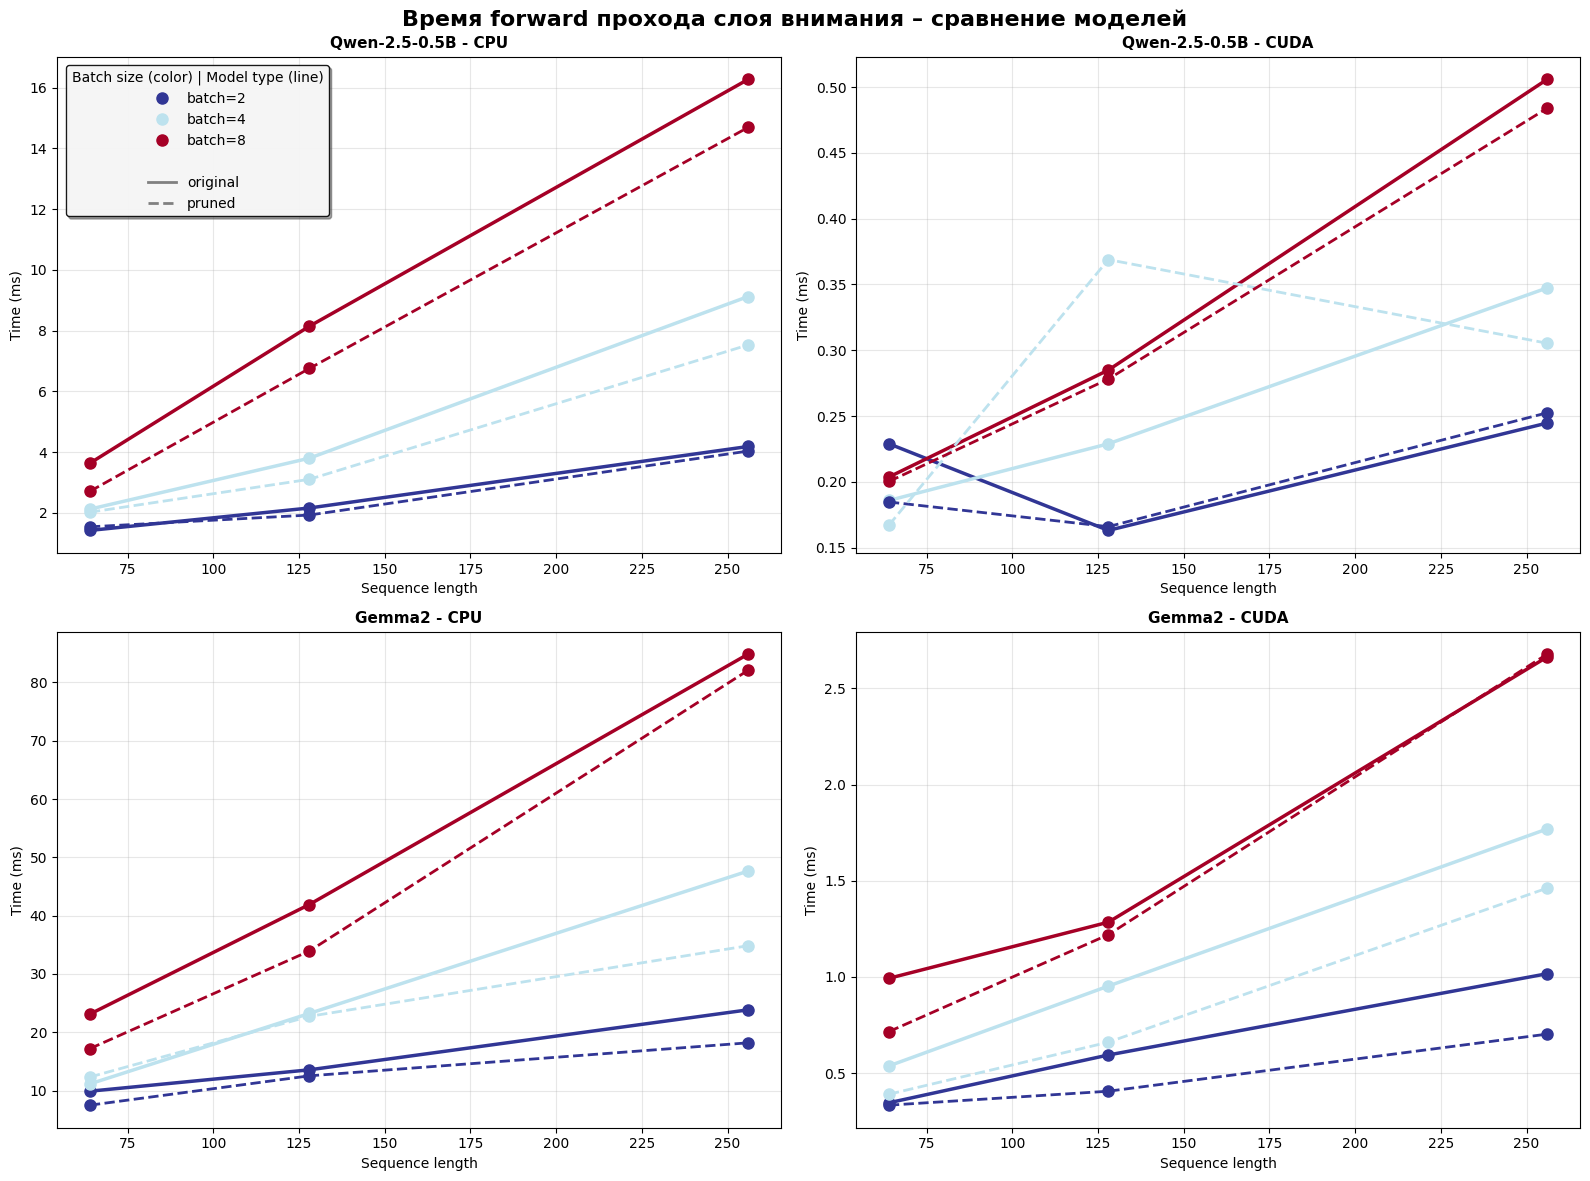

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import os


# Загрузка данных
df = pd.read_csv(csv_filename)
print(f'Данные загружены из - {csv_filename}')

# Функция для извлечения базового имени и типа модели
def parse_model(name):
    if "(original)" in name:
        return name.replace(" (original)", ""), "original"
    elif "(pruned)" in name:
        return name.replace(" (pruned)", ""), "pruned"
    else:
        return name, "unknown"

# Создаём новые колонки
df[['base_model', 'model_type']] = df['model'].apply(lambda x: pd.Series(parse_model(x)))

# Параметры визуализации
batch_sizes = sorted(df['batch_size'].unique())
devices = ['cpu', 'cuda']
marker = 'o'
linestyles = {'original': '-', 'pruned': '--'}
linewidths = {'original': 2.5, 'pruned': 2}

norm = Normalize(vmin=min(batch_sizes), vmax=max(batch_sizes))
cmap = plt.cm.RdYlBu_r
batch_colors = {bs: cmap(norm(bs)) for bs in batch_sizes}

available_models = df['base_model'].unique()
n_models = len(available_models)

# Создаём фигуру с подграфиками для всех моделей
# Для каждой модели: 1 строка, 2 столбца (CPU и GPU)
fig, axes = plt.subplots(n_models, 2, figsize=(16, 6 * n_models))
fig.suptitle('Время forward прохода слоя внимания – сравнение моделей', 
             fontsize=16, fontweight='bold')

# Если только одна модель, axes имеет размерность (2,)
if n_models == 1:
    axes = axes.reshape(1, -1)

# Создаём элементы для единой легенды
legend_elements = []

# Добавляем элементы для batch_size
for bs in batch_sizes:
    legend_elements.append(
        Line2D([0], [0], marker=marker, color=batch_colors[bs], 
               linestyle='None', markersize=8, label=f'batch={bs}')
    )

# Добавляем разделитель (пустая строка)
legend_elements.append(Line2D([0], [0], color='none', label=''))

# Добавляем элементы для типов линий
legend_elements.append(
    Line2D([0], [0], color='gray', linestyle='-', linewidth=2, label='original')
)
legend_elements.append(
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='pruned')
)

for idx, model in enumerate(available_models):
    for col_idx, device in enumerate(devices):
        ax = axes[idx, col_idx]
        device_df = df[(df['base_model'] == model) & (df['device'] == device)]
        
        if device_df.empty:
            ax.text(0.5, 0.5, f'Нет данных для {device.upper()}', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{model} - {device.upper()}')
            continue
        
        for mtype in ['original', 'pruned']:
            for bs in batch_sizes:
                subset = device_df[(device_df['batch_size'] == bs) & (device_df['model_type'] == mtype)]
                if subset.empty:
                    continue
                subset = subset.sort_values('seq_len')
                color = batch_colors[bs]
                
                ax.plot(subset['seq_len'], subset['time_ms'],
                        marker=marker, 
                        linestyle=linestyles[mtype],
                        color=color, 
                        linewidth=linewidths[mtype],
                        markersize=8)
        
        ax.set_xlabel('Sequence length', fontsize=10)
        ax.set_ylabel('Time (ms)', fontsize=10)
        ax.set_title(f'{model} - {device.upper()}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)

# Добавляем легенду в правый нижний угол всей фигуры
fig.legend(handles=legend_elements, loc='upper left', fontsize=10,
           framealpha=0.9, edgecolor='black', fancybox=True, shadow=True,
           title='Batch size (color) | Model type (line)',
           bbox_to_anchor=(0.04, 0.94))

plt.tight_layout()

# Сохраняем объединённый график
output_filename = os.path.splitext(csv_filename)[0] + "_combined.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Объединённый график сохранён: {output_filename}")

plt.show()
plt.close(fig)